In [9]:
#ZOO and label flip attacks on the RAI enhanced model

%run /home/jui/thesis-code/Thesis-code/RAI-implementation/Improved-model.ipynb

0    23364
1     6636
Name: default payment next month, dtype: int64
(30000, 25)
2    18112
1    18112
Name: SEX, dtype: int64
PR-AUC: 0.5775005059302372
Model Accuracy: 0.8419
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      7305
           1       0.66      0.37      0.47      1751

    accuracy                           0.84      9056
   macro avg       0.76      0.66      0.69      9056
weighted avg       0.82      0.84      0.82      9056


Final Training Log Loss: 0.3026
Final Test Log Loss: 0.3941


In [3]:
from art.estimators.classification import XGBoostClassifier
from art.attacks.evasion import ZooAttack
from art.estimators.classification import SklearnClassifier

import warnings
warnings.filterwarnings('ignore')

X_test_proc = pipeline.named_steps['preprocessor'].transform(X_test)

def get_adversarial_examples(X_train_subset, pipeline, model):
    # Extract the preprocessor and model from the pipeline
    preprocessor = pipeline.named_steps['preprocessor']

    # Preprocess the subset of training data using the pipeline's preprocessor
    X_train_subset_preprocessed = preprocessor.transform(X_train_subset)

    # Create ART classifier for XGBoost
    art_classifier = XGBoostClassifier(
        model=model,
        nb_features=X_train_subset_preprocessed.shape[1],
        nb_classes=2)

    # Create the ZooAttack instance
    zoo = ZooAttack(
        classifier=art_classifier,
        confidence=0.0,
        targeted=False,
        learning_rate=1e-1,
        max_iter=50,
        binary_search_steps=10,
        initial_const=1e-3,
        abort_early=True,
        use_resize=False,
        use_importance=False,
        nb_parallel=5,
        batch_size=1,
        variable_h=0.01
    )

    # Generate adversarial examples
    x_train_adv = zoo.generate(X_train_subset_preprocessed)

    return x_train_adv

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
x_train_adv = get_adversarial_examples(X_test, pipeline, model_improved)

ZOO:   0%|          | 0/9056 [00:00<?, ?it/s]

ZOO: 100%|██████████| 9056/9056 [22:10<00:00,  6.80it/s]  


In [5]:
import numpy as np

def calculate_metrics(adv_numpy, sample_numpy, std):
    """
    Calculate attack metrics between adversarial and clean samples.

    Parameters:
    - adv_numpy: np.array (1D) adversarial example (possibly preprocessed)
    - sample_numpy: np.array (1D) clean example (same space as adv_numpy)
    - adv_numpy_cont: np.array (1D) adversarial example in continuous/raw space (optional, for Mahalanobis)
    - train_mean: np.array mean vector of training data in continuous/raw space
    - train_cov_matrix: np.array covariance matrix of training data in continuous/raw space
    - threshold: float threshold for Mahalanobis distance outlier detection
    - std: np.array standard deviation vector of training data features (same length as adv_numpy)

    Returns: dict with keys:
    - "L0 Distance", "L1 Distance", "L2 Distance", "Linf Distance", "Sensitivity"
    """
    eps = 1e-8

    # Sparsity metric: count of features changed
    l0_distance = np.count_nonzero(adv_numpy - sample_numpy)

    # Proximity metrics: norms of difference
    diff = adv_numpy - sample_numpy
    l1_distance = np.linalg.norm(diff, ord=1)
    l2_distance = np.linalg.norm(diff, ord=2)
    linf_distance = np.linalg.norm(diff, ord=np.inf)

    # Sensitivity: normalized L1 per changed feature, averaged (avoid division by zero)
    if l0_distance == 0:
        sens = 0.0
    else:
        # std could have zeros, so clip to eps to avoid div by zero
        std_safe = np.clip(std, a_min=eps, a_max=None)
        sens = (l1_distance / (np.sum(std_safe) * l0_distance))

    return {
        "L0 Distance": l0_distance,
        "L1 Distance": l1_distance,
        "L2 Distance": l2_distance,
        "Linf Distance": linf_distance,
        "Sensitivity": sens,
    }

# Convert raw training data to numpy
X_train_np = X_train.to_numpy()

# Calculate mean, covariance, and std
train_mean = np.mean(X_train_np, axis=0)
train_cov_matrix = np.cov(X_train_np, rowvar=False)
train_std = np.std(X_train_np, axis=0)
metrics = calculate_metrics(x_train_adv, pipeline.named_steps['preprocessor'].transform(X_test), train_std)
print(metrics) 

{'L0 Distance': 52645, 'L1 Distance': 4674.508363731594, 'L2 Distance': 134.5626408050595, 'Linf Distance': 89.608155105263, 'Sensitivity': 1.7843986172847782e-07}


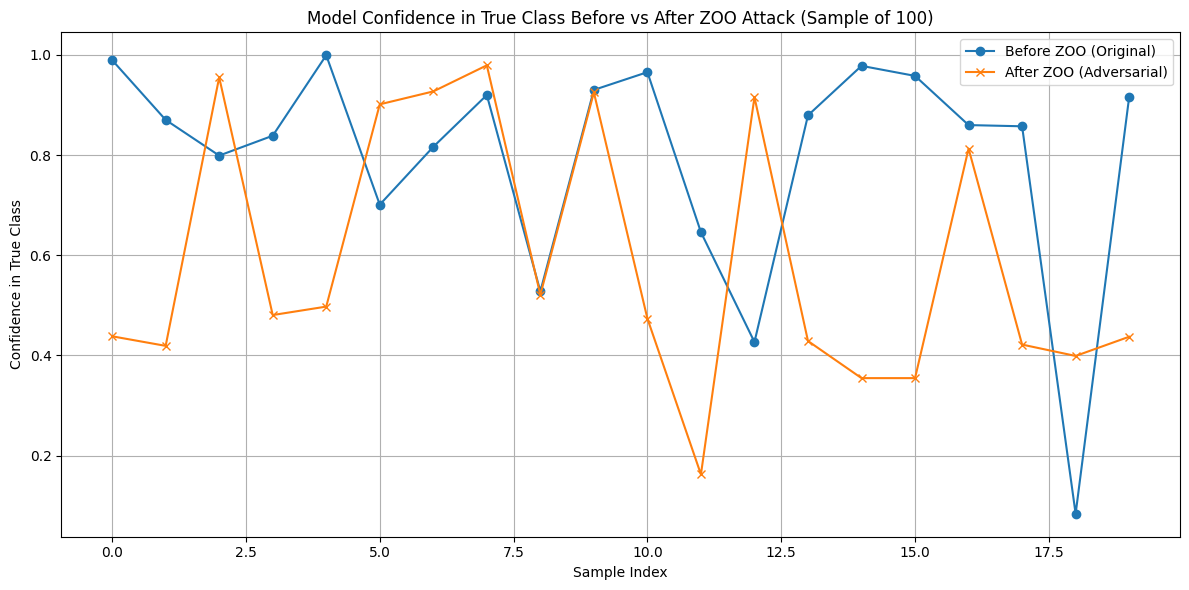

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Preprocess original data
X_orig_preprocessed = pipeline.named_steps['preprocessor'].transform(X_train)

# Predict probabilities on original and adversarial samples
y_probs_orig = model_improved.predict_proba(X_orig_preprocessed)
y_probs_adv = model_improved.predict_proba(x_train_adv)

# Get confidence in true class for each sample
true_class_conf_orig = [prob[y] for prob, y in zip(y_probs_orig, y_train)]
true_class_conf_adv = [prob[y] for prob, y in zip(y_probs_adv, y_train)]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(true_class_conf_orig[:20], label='Before ZOO (Original)', marker='o')
plt.plot(true_class_conf_adv[:20], label='After ZOO (Adversarial)', marker='x')
plt.title('Model Confidence in True Class Before vs After ZOO Attack (Sample of 100)')
plt.xlabel('Sample Index')
plt.ylabel('Confidence in True Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Accuracy on Test Set wihtout any defense: 39.97%


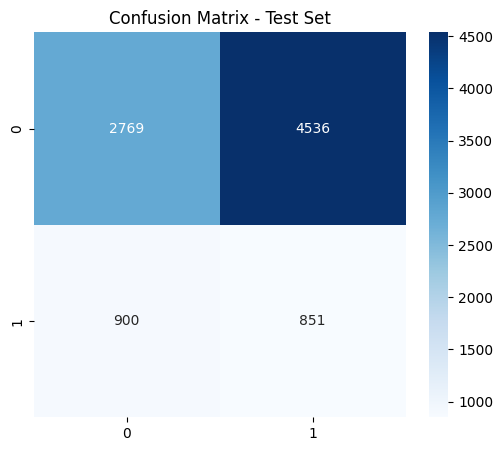

       L0 Distance  L1 Distance  L2 Distance  Linf Distance   Sensitivity
count  9056.000000  9056.000000  9056.000000    9056.000000  9.056000e+03
mean      5.813273     6.017174     2.017716       0.995606  1.127437e-06
std       5.027887     9.710225     3.082686       1.465179  1.655428e-06
min       0.000000     0.000000     0.000000       0.000000  0.000000e+00
25%       0.000000     0.000000     0.000000       0.000000  0.000000e+00
50%       6.000000     1.025396     0.440809       0.264591  3.434635e-07
75%      10.000000     8.952181     3.103404       1.588563  1.694815e-06
max      20.000000    89.608155    28.279304      16.319874  1.532872e-05
                Metric  Clean  Adversarial  Change
0             Accuracy 0.8419       0.3997 -0.4421
1             F1 Score 0.4747       0.2384 -0.2362
2            Precision 0.6636       0.1580 -0.5056
3               Recall 0.3695       0.4860  0.1165
4              ROC-AUC 0.7845       0.4794 -0.3052
5      Avg L0 Distance    Na

In [8]:
#without any defense, directly testing how much model is impacted

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


# Predictions on the test set (which is actually adversarial)
y_adv_pred = model_improved.predict(x_train_adv)
y_adv_proba = model_improved.predict_proba(x_train_adv).max(axis=1)

# Preprocess clean test data
X_test_proc = pipeline.named_steps['preprocessor'].transform(X_test)
x_train_adv_np = np.array(x_train_adv)

# Safety check
assert X_test_proc.shape == x_train_adv_np.shape, "Shape mismatch between clean and adversarial sets."

# Loop over each (clean, adversarial) pair and compute metrics
all_metrics = [
    calculate_metrics(adv_sample, clean_sample, train_std)
    for adv_sample, clean_sample in zip(x_train_adv_np, X_test_proc)
]

# Convert results to DataFrame
results_df = pd.DataFrame(all_metrics)

# Summary metrics
avg_l0 = results_df["L0 Distance"].mean()
avg_l2 = results_df["L2 Distance"].mean()
avg_linf = results_df["Linf Distance"].mean()

# Compute accuracy on the test set
accuracy_test = accuracy_score(y_test, y_adv_pred)
print(f"Accuracy on Test Set wihtout any defense: {accuracy_test * 100:.2f}%")

# Confusion Matrix for test data
cm_test = confusion_matrix(y_test, y_adv_pred)

# Plot Confusion Matrix for the test set
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()

# Drop in prediction confidence
confidence_drop = np.mean(y_adv_proba - y_proba)

# Attack success rate
attack_success_rate = np.mean(y_pred_improved != y_adv_pred)

# (Optional) Print full summary
print(results_df.describe())

# Metrics
metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1 Score",
        "Precision",
        "Recall",
        "ROC-AUC",
        "Avg L0 Distance",
        "Avg L2 Distance",
        "Avg Linf Distance",
        "Confidence Drop",
        "Attack Success Rate"
    ],
    "Clean": [
        accuracy_score(y_test, y_pred_improved),
        f1_score(y_test, y_pred_improved),
        precision_score(y_test, y_pred_improved),
        recall_score(y_test, y_pred_improved),
        roc_auc_score(y_test, model_improved.predict_proba(X_test_proc)[:, 1]),
        np.nan,  # L0 not meaningful for clean
        np.nan,  # L2 not meaningful for clean
        np.nan,  # Linf not meaningful for clean
        0.0,     # No confidence drop on clean
        0.0
    ],
    "Adversarial": [
        accuracy_score(y_test, y_adv_pred),
        f1_score(y_test, y_adv_pred),
        precision_score(y_test, y_adv_pred),
        recall_score(y_test, y_adv_pred),
        roc_auc_score(y_test, model_improved.predict_proba(x_train_adv)[:, 1]),
        avg_l0,
        avg_l2,
        avg_linf,
        confidence_drop,
        attack_success_rate
    ]
})

# Compute change for interpretation
metrics_table["Change"] = metrics_table["Adversarial"] - metrics_table["Clean"]

# Format table
pd.options.display.float_format = '{:.4f}'.format
print(metrics_table)

Accuracy on Test Set: 81.42%


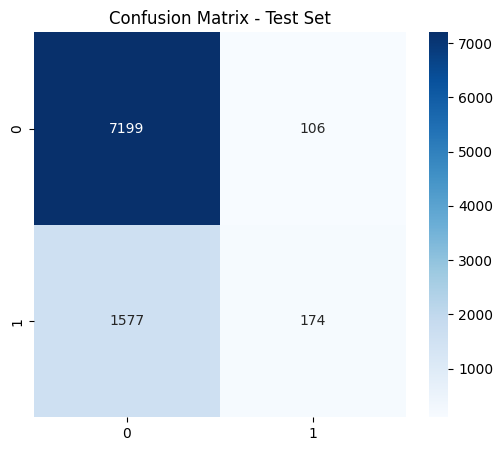

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Predictions on the test set (not the original or adversarial training data)
y_pred_test = model_improved.predict(X_test)

# Compute accuracy on the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy on Test Set: {accuracy_test * 100:.2f}%")

# Confusion Matrix for test data
cm_test = confusion_matrix(y_test, y_pred_test)

# Plot Confusion Matrix for the test set
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()


In [10]:
def label_flip_attack(y_train: np.ndarray, flip_percent: float) -> np.ndarray:
    """
    Flip labels in y_train by a specified percentage.
    
    Args:
        y_train (np.ndarray): Original training labels.
        flip_percent (float): Percentage of labels to flip (0-100).

    Returns:
        np.ndarray: Poisoned labels with flipped values.
    """
    y_poisoned = y_train.copy()
    n_samples = len(y_train)
    n_flip = int((flip_percent / 100) * n_samples)  # Number of labels to flip
    
    flip_indices = np.random.choice(np.arange(n_samples), size=n_flip, replace=False)

    # Flip binary labels (assuming labels are 0 and 1)
    y_poisoned[flip_indices] = 1 - y_poisoned[flip_indices]  # Flip 0->1 and 1->0
    
    return y_poisoned



Accuracy on Test Set: 77.96%


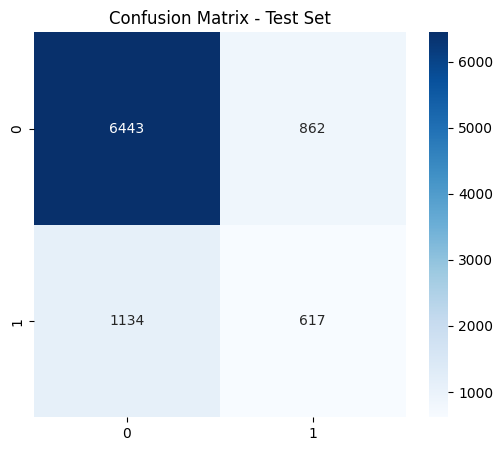

In [11]:
# Define the percentage of labels to flip
flip_percent = 35  # Flip 35% of labels

# Apply label flipping attack
y_train_poisoned = label_flip_attack(y_train, flip_percent)

# Step 2: Train model on poisoned labels
model_poisoned = xgb_model.fit(X_train, y_train_poisoned, verbose=False)
y_proba_poisoned = xgb_model.predict_proba(X_test)[:, 1]

# Step 3: Evaluate model on test set
y_pred_poisoned = model_poisoned.predict(X_test)
poisoned_accuracy = accuracy_score(y_test, y_pred_poisoned)
print(f"Accuracy on Test Set: {poisoned_accuracy * 100:.2f}%")

# Step 4: Confusion Matrix
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_poisoned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()

In [13]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_label_flip_impact(acc_clean, acc_poisoned, y_pred_clean, y_pred_poisoned, probs_clean, probs_poisoned, y_test):
    acc_drop = acc_clean - acc_poisoned

    # Prediction agreement / shift
    prediction_agreement = np.mean(y_pred_clean == y_pred_poisoned)
    prediction_shift_rate = 1 - prediction_agreement

    # Class distribution shift
    clean_counts = Counter(y_pred_clean)
    poisoned_counts = Counter(y_pred_poisoned)

    # Misclassification map (correct before, wrong after)
    correct_before = (y_pred_clean == y_test)
    wrong_after = (y_pred_poisoned != y_test)
    damaged_indices = np.where(correct_before & wrong_after)[0]
    damage_rate = len(damaged_indices) / len(y_test)

    # Confidence drop (optional)
    try:
        conf_clean = probs_clean  # already shape (7500,)
        conf_poisoned = probs_poisoned  # also 1D, same shape
        avg_conf_drop = np.mean(conf_clean - conf_poisoned)
    except AttributeError:
        avg_conf_drop = None  # model might not support predict_proba


    # Pack results into a dict
    results = {
        "Accuracy Clean": acc_clean,
        "Accuracy Poisoned": acc_poisoned,
        "Accuracy Drop": acc_drop,
        "Prediction Agreement": prediction_agreement,
        "Prediction Shift Rate": prediction_shift_rate,
        "Class Distribution Clean": dict(clean_counts),
        "Class Distribution Poisoned": dict(poisoned_counts),
        "Damage Rate": damage_rate,
        "Damaged Indices": damaged_indices,
        "Average Confidence Drop": avg_conf_drop,
    }

    return results

metrics = evaluate_label_flip_impact(accuracy, poisoned_accuracy, y_pred_improved, y_pred_poisoned, y_proba, y_proba_poisoned, y_test)
print(metrics)

{'Accuracy Clean': 0.8418727915194346, 'Accuracy Poisoned': 0.7795936395759717, 'Accuracy Drop': 0.062279151943462896, 'Prediction Agreement': 0.8710247349823321, 'Prediction Shift Rate': 0.12897526501766787, 'Class Distribution Clean': {0: 8081, 1: 975}, 'Class Distribution Poisoned': {1: 1479, 0: 7577}, 'Damage Rate': 738.5503533568905, 'Damaged Indices': array([   0,    0,    0, ..., 9055, 9055, 9055]), 'Average Confidence Drop': -0.34667757}
